# Linear algebra and loss intuition

Runnable locally on CPU or on a Cloud TPU VM.

- Map one row to one prediction
- Calculate loss before differentiating
- Expose a broadcast that changes the problem
- Change the dataset and retain the contract
- Derive the vector gradient from individual errors

Let’s build a regression prediction one row at a time. Each feature gets a weight, and a bias shifts the result. Once we can calculate three predictions ourselves, we’ll write the matrix version and its loss. This small check will help us catch a transposed array or an accidental broadcast before training begins.

## The idea

Represent observations as rows and features as columns. The matrix $X\in\mathbb{R}^{n\times d}$ contains $n$ observations with $d$ features each, and $w\in\mathbb{R}^{d}$ assigns a weight to each feature. Multiplying gives one weighted sum per observation; in Python, this is `X @ w`.

A scalar bias shifts every prediction, giving $\hat y=Xw+b\mathbf{1}$, where $\mathbf{1}$ is the vector of ones. Predictions and targets should both have shape $(n,)$. Subtract them element by element, square the residuals and average to obtain one scalar mean squared loss. A mistaken $(n,n)$ residual matrix compares every prediction with every target, changing the problem even though its mean is still a scalar.

## Calculate one complete loss by hand

Use a small worked case: $X=[[1,2],[3,0]]$, $w=[2,-1]$, and $b=1$. The predictions are $1(2)+2(-1)+1=1$ and $3(2)+0(-1)+1=7$. With targets $[2,5]$, the residuals are $[-1,2]$, their squares are $[1,4]$, and the mean squared loss is $2.5$.

Notice where each axis goes. The feature axis disappears in the dot product; the observation axis remains until the final average. In general, $X$ has shape $(n,d)$, $w$ has shape $(d,)$, and predictions and targets both have shape $(n,)$.

The prediction plot shows the effect of changing bias: every point moves by the same amount. Changing a weight instead affects an observation in proportion to its corresponding feature. Compare those two interventions before treating all parameter updates as interchangeable.

### Pause and reason

If you duplicate every observation and target, does mean squared loss double?

<details><summary>Compare your reasoning</summary>

No. Both the squared-error sum and the observation count double, leaving the mean unchanged. A summed loss would double, and its gradient scale would change too.

</details>

## Map one row to one prediction

Our three observations have two features each. The first row selects weight $0$, the second selects weight $1$, and the third adds both weights. With $w=[2, -1]$ and bias $1$, the predictions are therefore $[3, 0, 2]$. Matrix multiplication performs these three dot products together. It does not turn the bias into another feature unless you explicitly augment the design matrix.

Write the shapes beside each quantity before executing. The feature axis disappears through the dot product; the observation axis survives. This is the same contract you will use when replacing this tiny dataset with a data loader.

```text
X (3, 2) × w (2,) → prediction (3,)
                                  + scalar bias
prediction − target (3,) → residual (3,)
mean(residual²) → scalar loss
```

## Calculate loss before differentiating

With bias zero the prediction is $[2, -1, 1]$. Subtracting $[3, 0, 2]$ gives three residuals of $-1$. Squaring gives $[1, 1, 1]$; their mean is $1$. The sign convention matters when you later derive the gradient even though either residual sign produces the same squared loss.

For residual $r=Xw+b\mathbf{1}-y$, the gradients are $\frac{2}{n}X^\mathsf{T}r$ and $2\operatorname{mean}(r)$ for weights and bias respectively. At this point they are $[-4/3, -4/3]$ and $-2$. This hand calculation is an independent test of both the model and the reduction axis. Here $r$ is the vector of residuals, $n$ counts observations, and $\mathbf{1}$ repeats the scalar bias for every row. The transpose $X^\mathsf{T}$ gathers each feature’s contribution to its weight gradient.

$$
\begin{aligned}r&=Xw+b\mathbf{1}-y\\L&=\frac{1}{n}\sum_{i=1}^{n}r_i^2\\\nabla_w L&=\frac{2}{n}X^\mathsf{T}r,\qquad\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}r_i\end{aligned}
$$

## Expose a broadcast that changes the problem

A column target of shape $(3, 1)$ and predictions of shape $(3,)$ combine into a $(3, 3)$ residual matrix. Each target is compared with every prediction. At the parameters that exactly fit our observations, this wrong loss is $28/9$ rather than zero. JAX is following the array rules correctly; the data contract is wrong.

Check shapes at the loss boundary instead of hoping a small loss will reveal the mistake. Flattening is appropriate only when the original column really represents one scalar per observation; flattening multi-output targets would discard their meaning.

## Change the dataset and retain the contract

The supplied dataset is deliberately easy to compute by hand. Test a new row $[2, -1]$: its weighted sum is $5$ and its prediction with bias $1$ is $6$. Include this row and its target, then verify zero loss. A test that only uses the training rows cannot detect every feature-order mistake.

A mean reduction makes duplicating the entire dataset leave the loss unchanged; a sum reduction would double it. Neither convention is inherently invalid, but it changes gradient scale and therefore affects the interpretation of a learning rate.

## Derive the vector gradient from individual errors

For observation $i$, the residual is $r_i=x_i^\mathsf{T}w+b-y_i$. Its derivative with respect to the weights is the feature row $x_i$. The chain rule multiplies this by $2r_i$, and averaging combines all observations. This gives $\nabla_w L=2X^\mathsf{T}r/n$, while the bias derivative is twice the mean residual. A sum loss has gradients $n$ times as large as a mean loss. Neither convention is inherently wrong, but the same learning rate then represents a different update. Use the direct solver in the next lesson to obtain a reference fit before diagnosing iterative training.

$$
\nabla_w L=\frac{2}{n}X^\mathsf{T}(Xw+b\mathbf1-y),\qquad \frac{\partial L}{\partial b}=\frac{2}{n}\sum_i r_i
$$

## 1. Prepare the inputs

Create a file named main.py in your activated learning environment. Add these imports and inputs first. Shapes and numeric types are part of the experiment.

In [1]:
# Step 1 — 1. Prepare the inputs: This block establishes the values used by the following steps; run...
# Import jax for this computation.
import jax
import jax.numpy as jnp

This block establishes the values used by the following steps; run the completed file after step $3$.

## 2. Define the computation

Append this block below the inputs. Before proceeding, trace which values are inputs, predictions, and state.

In [2]:
# Step 2 — 2. Define the computation: predict contracts the feature axis through Xw.
# Initialize array `X` with explicit values and shape.
X = jnp.array([[1., 0.], [0., 1.], [1., 1.]])
# Initialize array `w` with explicit values and shape.
w = jnp.array([2., -1.])
# Initialize array `targets` with explicit values and shape.
targets = jnp.array([3., 0., 2.])
# Function `predict(w, bias, X)` implementing this stage's computation:
def predict(w, bias, X):
    # Return `X @ w + bias` to the caller.
    return X @ w + bias
# Function `mse(w, bias)` implementing this stage's computation:
def mse(w, bias):
    # Run `predict` to compute `prediction`.
    prediction = predict(w, bias, X)
    # Verify that the output tensor shape matches our prediction.
    assert prediction.shape == targets.shape
    # Return `jnp.mean((prediction - targets) ** 2)` to the caller.
    return jnp.mean((prediction - targets) ** 2)

predict contracts the feature axis through $Xw$. mse checks row alignment before subtraction, squares each residual, and reduces to one scalar.

## 3. Measure and verify

Append the remaining block, then run python main.py in the terminal. Compare the printed result with the expected output below. Assertions stop execution if the contract fails.

In [3]:
# Step 3 — 3. Measure and verify: Predictions: [3., 0., 2.]; Loss: 0.0.
# Print the observed values to compare against the expected result.
print("Predictions:", predict(w, 1., X))
# Print diagnostic summary of the computed outputs.
print("Loss:", float(mse(w, 1.)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(predict(w, 1., X), targets)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(mse(w, 1.), 0.)

Predictions: [3. 0. 2.]
Loss: 0.0


Predictions: $[3., 0., 2.]$; Loss: $0.0$.

## Run the example

In [4]:
# Step 1 — 1. Prepare the inputs: This block establishes the values used by the following steps; run...
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Step 2 — 2. Define the computation: predict contracts the feature axis through Xw.
# Initialize array `X` with explicit values and shape.
X = jnp.array([[1., 0.], [0., 1.], [1., 1.]])
# Initialize array `w` with explicit values and shape.
w = jnp.array([2., -1.])
# Initialize array `targets` with explicit values and shape.
targets = jnp.array([3., 0., 2.])
# Function `predict(w, bias, X)` implementing this stage's computation:
def predict(w, bias, X):
    # Return `X @ w + bias` to the caller.
    return X @ w + bias
# Function `mse(w, bias)` implementing this stage's computation:
def mse(w, bias):
    # Run `predict` to compute `prediction`.
    prediction = predict(w, bias, X)
    # Verify that the output tensor shape matches our prediction.
    assert prediction.shape == targets.shape
    # Return `jnp.mean((prediction - targets) ** 2)` to the caller.
    return jnp.mean((prediction - targets) ** 2)
# Step 3 — 3. Measure and verify: Predictions: [3., 0., 2.]; Loss: 0.0.
# Print the observed values to compare against the expected result.
print("Predictions:", predict(w, 1., X))
# Print diagnostic summary of the computed outputs.
print("Loss:", float(mse(w, 1.)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(predict(w, 1., X), targets)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(mse(w, 1.), 0.)

Predictions: [3. 0. 2.]
Loss: 0.0


Expected: Predictions: $[3., 0., 2.]$; Loss: $0.0$.

## A scalar bias shifts every prediction

Predict: What residual appears when the bias changes from $1$ to $0$?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: A scalar bias shifts every prediction
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'bar', 'labels': ['observation 0', 'observation 1', 'observation 2'], 'ylabel': 'target / prediction', 'series': [{'label': 'target', 'y': targets.tolist()}, {'label': 'bias 1', 'y': predict(w, 1.0, X).tolist()}, {'label': 'bias 0', 'y': predict(w, 0.0, X).tolist()}]}

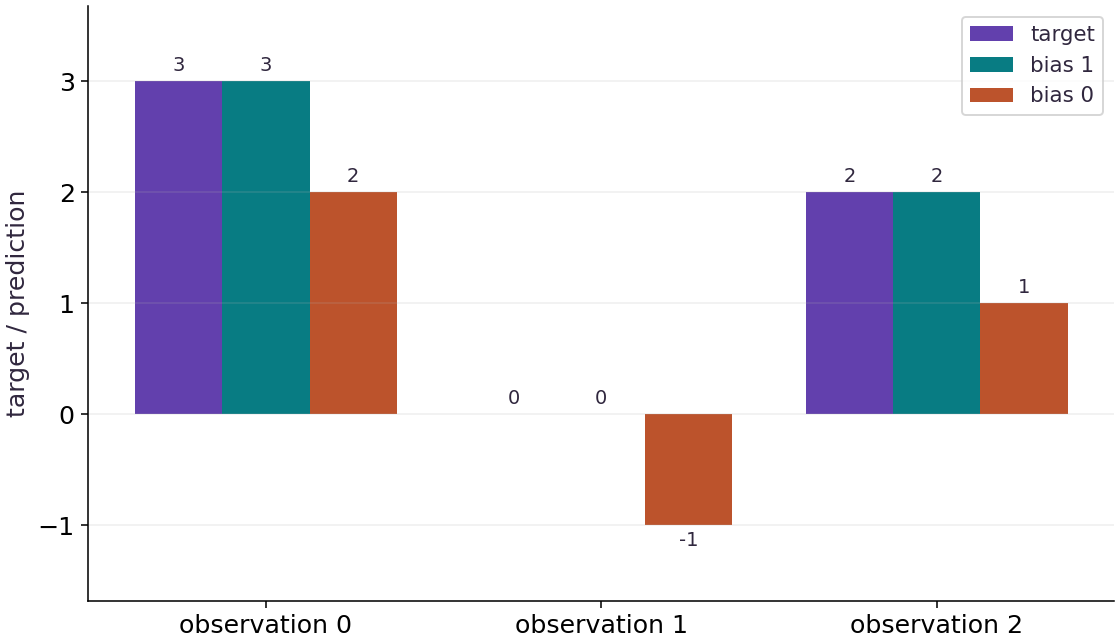

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each group of bars corresponds to one observation. The vertical axis contains targets and predictions, not losses. Within each group, compare the target with predictions using bias $1$ and bias $0$.

With bias $1$, the predictions $(3,0,2)$ have the same heights as the targets. With bias $0$, they become $(2,-1,1)$: every prediction is exactly one unit lower. The negative bar in the middle group is a negative prediction, not a negative squared error.

### Connect it to the computation

The matrix-vector product produces one value per observation, and the scalar bias is added to each value. Holding the weights fixed while removing the bias therefore shifts all predictions by the same amount.

For bias $0$, the prediction-minus-target residual is $-1$ on every row. Squaring and averaging gives $(1+1+1)/3=1$. With bias $1$, all residuals are zero and the mean squared loss is zero. Read the gaps between bars to understand the loss; do not average the bar heights themselves.

## Verify the gradient by hand

Predict: At bias zero, what are the weight and bias derivatives?

In [7]:
# Experiment — Verify the gradient by hand: The matrix formula and autodiff agree for the same row-matched...
# Differentiate the objective to obtain `(gw, gb)` via automatic differentiation.
gw, gb = jax.grad(mse, argnums=(0, 1))(w, 0.)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(gw, jnp.array([-4/3, -4/3]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(gb, -2.)
# Print the observed values to compare against the expected result.
print("Analytic gradients:", gw, gb)

Analytic gradients: [-1.3333334 -1.3333334] -2.0


Expected: Weight gradient ≈ $[-1.333333, -1.333333]$; bias gradient $-2$.

The matrix formula and autodiff agree for the same row-matched scalar objective.

## Make the silent shape error visible

Predict: Does an exact model still have zero loss against column targets?

In [8]:
# Experiment — Make the silent shape error visible: A valid broadcast can define an unintended objective without...
column_targets = targets[:, None]
# Run `predict` to compute `pairwise`.
pairwise = predict(w, 1., X) - column_targets
# Verify that the output tensor shape matches our prediction.
assert pairwise.shape == (3, 3)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.mean(pairwise**2), 28/9)
# Print the observed values to compare against the expected result.
print("Wrong residual shape:", pairwise.shape)

Wrong residual shape: (3, 3)


Expected: $(3, 3)$, with loss $28/9$.

A valid broadcast can define an unintended objective without raising an exception.

## Change the reduction, predict the update

Predict: For the same three residuals, how much larger is the gradient of a sum loss than a mean loss?

In [9]:
# Experiment — Change the reduction, predict the update: Loss reduction is part of the optimization specification.
def mean_objective(weights):
    # Return `jnp.mean((X @ weights - targets) ** 2)` to the caller.
    return jnp.mean((X @ weights - targets)**2)
# Function `sum_objective(weights)` implementing this stage's computation:
def sum_objective(weights):
    # Return `jnp.sum((X @ weights - targets) ** 2)` to the caller.
    return jnp.sum((X @ weights - targets)**2)
# Initialize array `point` with explicit values and shape.
point = jnp.array([0.2, -0.4])
# Perform matrix contraction / projection to compute `residual`.
residual = X @ point - targets
# Perform matrix contraction / projection to compute `analytic_mean`.
analytic_mean = 2 * X.T @ residual / X.shape[0]
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jax.grad(mean_objective)(point), analytic_mean, atol=1e-6)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jax.grad(sum_objective)(point), X.shape[0]*analytic_mean, atol=1e-6)

Expected: The sum gradient is $3$ times the mean gradient.

Loss reduction is part of the optimization specification. Match it when comparing hand calculations, libraries and learning rates.

## Your exercise

Set the bias to zero. Predict each residual and calculate the loss by hand, then compare it with JAX.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Verify that the numerical values match the expected reference within tolerance.
2. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Set the bias to zero.
residual = predict(...)  # TODO: compute residual
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(residual, -jnp.ones(3))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(mse(w, 0.), 1.)  # TODO: complete assertion check
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Set the bias to zero.
# residual = predict(...)  # TODO: compute residual
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(residual, -jnp.ones(3))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(mse(w, 0.), 1.)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [11]:
# Exercise solution: Set the bias to zero.
residual = predict(w, 0., X) - targets
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(residual, -jnp.ones(3))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(mse(w, 0.), 1.)

## Add an unseen observation · Transfer / diagnosis

Extend $X$ with $[2, -1]$, supply its target, and check predictions using ordinary arithmetic.

Hint: The new target is the dot product plus bias.

### How to write: Add an unseen observation — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `X_new` with explicit values and shape.
2. Initialize array `y_new` with explicit values and shape.
3. Verify that the numerical values match the expected reference within tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Add an unseen observation (Transfer / diagnosis): The fourth row checks a combination absent from the original...
# Initialize array `X_new` with explicit values and shape.
X_new = jnp.concatenate(...)  # TODO: compute X_new
# Initialize array `y_new` with explicit values and shape.
y_new = jnp.concatenate(...)  # TODO: compute y_new
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(predict(w, 1., X_new), y_new)  # TODO: complete assertion check
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Add an unseen observation (Transfer / diagnosis): The fourth row checks a combination absent from the original...
# Initialize array `X_new` with explicit values and shape.
# X_new = jnp.concatenate(...)  # TODO: compute X_new
# Initialize array `y_new` with explicit values and shape.
# y_new = jnp.concatenate(...)  # TODO: compute y_new
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(predict(w, 1., X_new), y_new)  # TODO: complete assertion check

## Reference reasoning

The fourth row checks a combination absent from the original three observations.

In [13]:
# Add an unseen observation (Transfer / diagnosis): The fourth row checks a combination absent from the original...
# Initialize array `X_new` with explicit values and shape.
X_new = jnp.concatenate([X, jnp.array([[2., -1.]])])
# Initialize array `y_new` with explicit values and shape.
y_new = jnp.concatenate([targets, jnp.array([6.])])
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(predict(w, 1., X_new), y_new)

## Reject and repair a column target · Transfer / diagnosis

Write a loss that rejects mismatched prediction/target shapes. Demonstrate rejection and then restore the intended one-target-per-row format.

Hint: Compare shapes before subtraction; reshape only this known scalar-target dataset.

### How to write: Reject and repair a column target — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).

**Step-by-step implementation plan:**
1. Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
2. Return `jnp.mean((prediction - target) ** 2)` to the caller.
3. Run the boundary check and catch the expected exception:
4. Verify contract: `checked_loss(predict(w, 1.0, X), column_targets[:, 0]) == 0`.

**Starter code scaffold (fill in the TODOs):**

```python
# Reject and repair a column target (Transfer / diagnosis): The failure is reproduced at the boundary and the repair is...
def checked_loss(prediction, target):
    # Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
    if prediction.shape != target.shape:
        raise ValueError("one target required per prediction")
    # Return `jnp.mean((prediction - target) ** 2)` to the caller.
    return ...  # TODO: return computed result
# Run the boundary check and catch the expected exception:
try:
    checked_loss(predict(w, 1., X), column_targets)
except ValueError:
    pass
else:
    raise AssertionError("bad shape accepted")
# Verify contract: `checked_loss(predict(w, 1.0, X), column_targets[:, 0]) == 0`.
assert checked_loss(predict(w, 1., X), column_targets[:, 0])  # TODO: complete assertion check
```

In [14]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reject and repair a column target (Transfer / diagnosis): The failure is reproduced at the boundary and the repair is...
# def checked_loss(prediction, target):
    # Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
#     if prediction.shape != target.shape:
#         raise ValueError("one target required per prediction")
    # Return `jnp.mean((prediction - target) ** 2)` to the caller.
#     return ...  # TODO: return computed result
# Run the boundary check and catch the expected exception:
# try:
#     checked_loss(predict(w, 1., X), column_targets)
# except ValueError:
#     pass
# else:
#     raise AssertionError("bad shape accepted")
# Verify contract: `checked_loss(predict(w, 1.0, X), column_targets[:, 0]) == 0`.
# assert checked_loss(predict(w, 1., X), column_targets[:, 0])  # TODO: complete assertion check

## Reference reasoning

The failure is reproduced at the boundary and the repair is verified against zero residuals.

In [15]:
# Reject and repair a column target (Transfer / diagnosis): The failure is reproduced at the boundary and the repair is...
def checked_loss(prediction, target):
    # Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
    if prediction.shape != target.shape:
        raise ValueError("one target required per prediction")
    # Return `jnp.mean((prediction - target) ** 2)` to the caller.
    return jnp.mean((prediction-target)**2)
# Run the boundary check and catch the expected exception:
try:
    checked_loss(predict(w, 1., X), column_targets)
except ValueError:
    pass
else:
    raise AssertionError("bad shape accepted")
# Verify contract: `checked_loss(predict(w, 1.0, X), column_targets[:, 0]) == 0`.
assert checked_loss(predict(w, 1., X), column_targets[:, 0]) == 0

## Checkpoint

What shape should one scalar target per observation have for predictions of shape $(n,)$?

1. $(n, 1)$
2. $(n,)$
3. $(d,)$

## Diagnose

Check prediction and target shapes before blaming the optimizer. For this dataset, all residuals with bias zero are $-1$, so the mean squared loss must be $1$.

## Evidence

Keep the row-by-row predictions, analytic weight/bias derivatives, pairwise-broadcast counterexample, and checked-loss rejection/repair. Include the analytic vector-gradient derivation and mean-versus-sum comparison.

## Carry forward

- The matrix formula and autodiff agree for the same row-matched scalar objective.
- A valid broadcast can define an unintended objective without raising an exception.

## Primary references

- [JAX array operations](https://docs.jax.dev/en/latest/jax.numpy.html)
- [Autodiff cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)